# Simple Linear Regression

This notebook guides you through fitting and evaluating a simple linear regression model on a synthetic 1D dataset.

## Learning objectives
- Build intuition for the linear regression hypothesis $\hat y = w_0 + w_1 x$.
- Derive and implement the closed-form (normal) equation.
- Implement gradient descent and study convergence.
- Compare models with and without $L_2$ regularization.
- Interpret residuals and error metrics.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')


## Generate a toy dataset (already done)
We sample points from a noisy line. Run the cell below to visualize; use the plot as a mental model for the tasks.

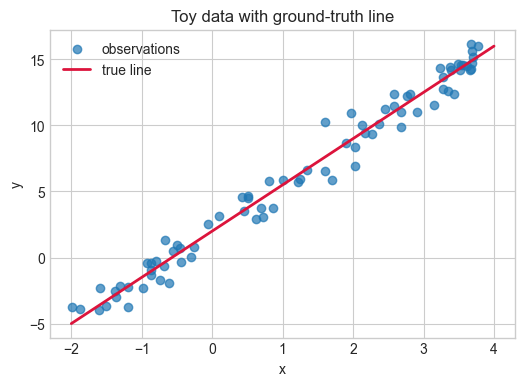

In [2]:
# Synthetic data generator (illustration)
rng = np.random.default_rng(12)
N = 80
true_w0, true_w1 = 2.0, 3.5
X = rng.uniform(-2, 4, size=N)
noise = rng.normal(0, 1.0, size=N)
y = true_w0 + true_w1 * X + noise

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X, y, alpha=0.7, label='observations')
ax.plot(np.linspace(-2,4,50), true_w0 + true_w1*np.linspace(-2,4,50), color='crimson', lw=2, label='true line')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_title('Toy data with ground-truth line')
plt.show()



**Result interpretation:** The scatter should cluster around the red ground-truth line $y = 2 + 3.5x$. Noise $\sim \mathcal{N}(0,1)$ creates vertical spread, but the positive slope remains clear.



## Derive the normal equation (pen & paper, then type answer)
**Question:** Starting from the mean squared error (MSE)
$$
J(\mathbf{w}) = \frac{1}{2m}\sum_{i=1}^m (\hat y^{(i)} - y^{(i)})^2,
$$
show that the optimal weights satisfy
$$
\mathbf{w} = (X^\top X)^{-1}X^\top \mathbf{y}.
$$

**Answer (sketch):** Using matrix form $J = \tfrac{1}{2m}\|X\mathbf{w}-\mathbf{y}\|_2^2$, take gradient $\nabla_{\mathbf{w}}J=\tfrac{1}{m}X^\top(X\mathbf{w}-\mathbf{y})$. Set to zero: $X^\top X\,\mathbf{w}=X^\top\mathbf{y}$. Assuming $X^\top X$ invertible, multiply both sides by $(X^\top X)^{-1}$ to obtain the normal equation above.


## Implement closed-form solution
Complete the function below to compute $w_0$ and $w_1$ via the normal equation. Use the bias trick by augmenting $X$ with a column of ones.

In [3]:
import numpy as np

def normal_equation_weights(X, y):
    """Return w0, w1 estimated by the normal equation."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    design = np.c_[np.ones_like(X), X]
    w = np.linalg.inv(design.T @ design) @ (design.T @ y)
    return float(w[0]), float(w[1])

w0_hat, w1_hat = normal_equation_weights(X, y)
print(f"Closed-form weights: w0={w0_hat:.3f}, w1={w1_hat:.3f}")


Closed-form weights: w0=2.007, w1=3.475



**Result:** The closed-form fit should print weights close to the true parameters (about $w_0 \approx 2$, $w_1 \approx 3.5$), with small deviations from sampling noise.



## Gradient descent
**Question:** Implement batch gradient descent for the same model. Use the cost
$$
J(w_0, w_1) = \frac{1}{2m} \sum_{i=1}^m (w_0 + w_1 x^{(i)} - y^{(i)})^2.
$$
Fill in the gradients, code, and study convergence.

**Answers:**
- Gradients: $\partial J/\partial w_0 = \tfrac{1}{m}\sum (\hat y^{(i)}-y^{(i)})$, $\partial J/\partial w_1 = \tfrac{1}{m}\sum (\hat y^{(i)}-y^{(i)})x^{(i)}$.
- Implementation and convergence plot are in the next code cell.


Gradient-descent weights: w0=2.007, w1=3.475


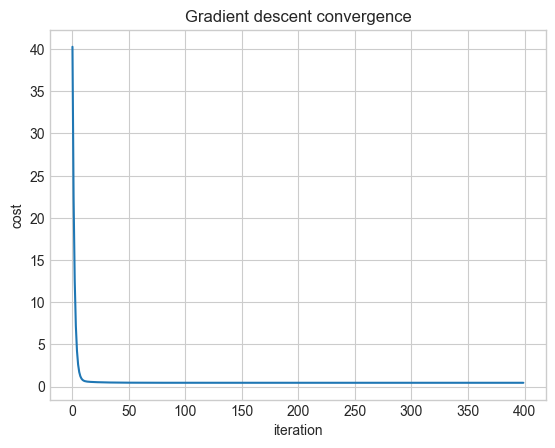

In [4]:
def gradient_descent(X, y, alpha=0.05, num_iters=400):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    w0, w1 = 0.0, 0.0
    history = []
    for t in range(num_iters):
        y_hat = w0 + w1 * X
        error = y_hat - y
        grad_w0 = error.mean()
        grad_w1 = (error * X).mean()
        w0 -= alpha * grad_w0
        w1 -= alpha * grad_w1
        cost = (error ** 2).mean() / 2
        history.append(cost)
    return w0, w1, history

w0_gd, w1_gd, history = gradient_descent(X, y, alpha=0.05, num_iters=400)
print(f"Gradient-descent weights: w0={w0_gd:.3f}, w1={w1_gd:.3f}")
plt.plot(history)
plt.xlabel('iteration')
plt.ylabel('cost')
plt.title('Gradient descent convergence')
plt.show()



**Result:** The cost curve should decrease smoothly to a small value. Final GD weights should be near the closed-form solution. If the curve diverges, lower $\alpha$; if it plateaus high, try a modestly larger $\alpha$ or more iterations.



## Add $L_2$ regularization (ridge)
**Question:** Modify the closed-form solution to include a regularization strength $\lambda$: 
$$
\mathbf{w}_{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top \mathbf{y}.
$$

**Answer (discussion):** Increasing $\lambda$ shrinks weights toward 0, which reduces variance and improves numerical stability, at the cost of introducing bias. Small $\lambda$ keeps the fit close to OLS; very large $\lambda$ drives the slope toward 0 (underfit). The next code cell implements `ridge_closed_form`.


In [5]:
def ridge_closed_form(X, y, lam=1.0):
    """Return w0, w1 for ridge regression with strength lam."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    design = np.c_[np.ones_like(X), X]
    A = design.T @ design + lam * np.eye(2)
    w = np.linalg.inv(A) @ (design.T @ y)
    return float(w[0]), float(w[1])

w0_ridge, w1_ridge = ridge_closed_form(X, y, lam=1.0)
print(f"Ridge (λ=1.0) weights: w0={w0_ridge:.3f}, w1={w1_ridge:.3f}")


Ridge (λ=1.0) weights: w0=1.987, w1=3.471



**Result:** Ridge weights shrink slightly toward zero compared with OLS. Increasing $\lambda$ amplifies shrinkage and stabilizes fits when $X^\top X$ is ill-conditioned.



## Residual analysis
**Question:** After fitting a model, plot residuals $r^{(i)} = \hat y^{(i)} - y^{(i)}$ vs. $x^{(i)}$. What pattern would signal model misspecification?

**Answer:** A good fit shows residuals scattered randomly around 0 with constant spread. Curved patterns suggest nonlinearity; funnel shapes suggest heteroscedasticity. The next code cell draws the residual plot.


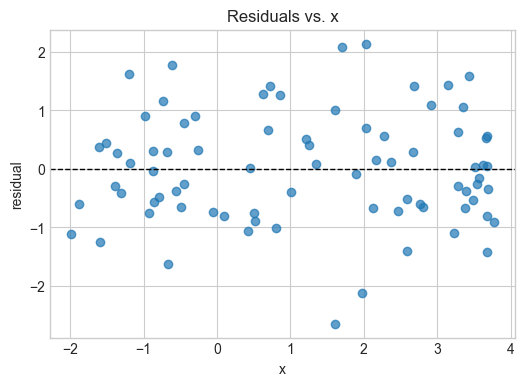

In [6]:
# Residual plot using closed-form estimator
residuals = (w0_hat + w1_hat * X) - y
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X, residuals, alpha=0.7)
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('residual')
ax.set_title('Residuals vs. x')
plt.show()



**Result interpretation:** Residuals should hover randomly around 0 with roughly constant spread. Visible curves suggest nonlinearity; funnels suggest heteroscedasticity.
